In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

from config import *

In [2]:
df = pd.read_parquet("../data/score_dataset_48h.parquet")
df.tail()

,fen,next_move,played_by_elo,win_pov,games_count,engine_move,delta,fragility_score,variance
1001886,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,d7d5,1834,False,145903,g8f6,-8.0,0.025806,107.640847
1001887,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,c1f4,1835,True,145903,c2c4,-31.0,0.022581,640.654900
1001888,rnbqkbnr/ppp1pppp/8/3p4/3P1B2/8/PPP1PPPP/RN1QK...,c7c6,1834,False,10250,e7e6,-37.0,0.038710,256.976193
1001889,rnbqkbnr/pp2pppp/2p5/3p4/3P1B2/8/PPP1PPPP/RN1Q...,g1f3,1835,True,2449,e2e3,-28.0,0.145161,1378.134736
1001890,rnbqkbnr/pp2pppp/2p5/3p4/3P1B2/5N2/PPP1PPPP/RN...,c8g4,1834,False,156,c8f5,-41.0,0.158065,552.037372


In [3]:
scaler = StandardScaler()
df[FEATURES] = scaler.fit_transform(df[FEATURES])

elo_stats = pd.DataFrame(index=ELOS, columns=FEATURES, dtype=float)

for elo in ELOS:
    mask = df["played_by_elo"].between(elo - ELO_DEV, elo + ELO_DEV)
    group = df.loc[mask, FEATURES]
    elo_stats.loc[elo, :] = group.mean().values

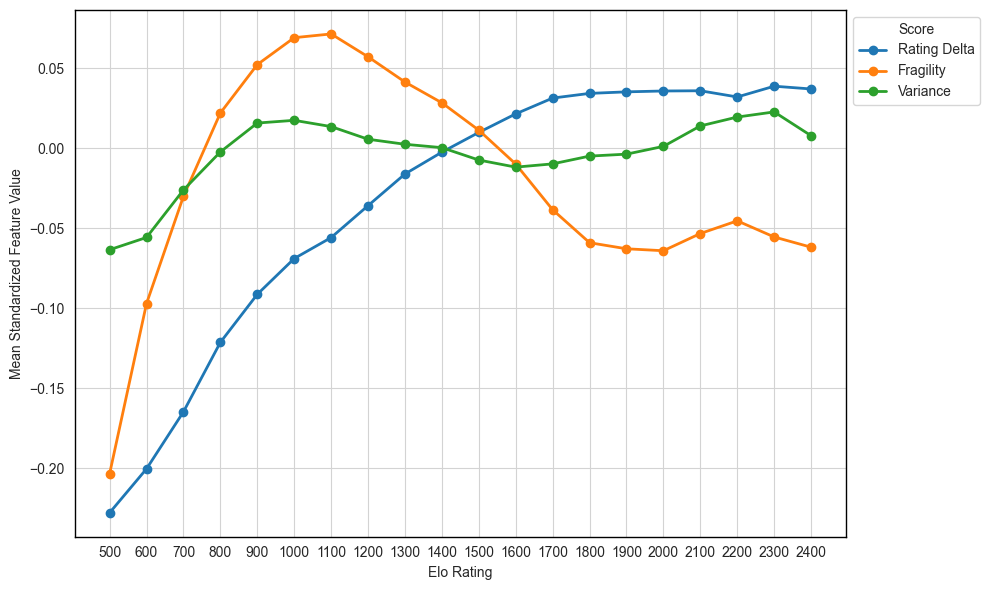

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = elo_stats[feature].values
    plt.plot(elo_stats.index, y, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Mean Standardized Feature Value")
plt.xticks(elo_stats.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Score",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_means.pdf")
plt.show()